# HR Attrition Early Warning System



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\hr_attrition_early_warning_system\data\attrition.csv')

In [3]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Basic Exploration

In [4]:
data.shape

(1470, 35)

In [5]:
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Null Check and Data Quality

In [7]:
data.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
data.duplicated().sum() 

np.int64(0)

In [9]:
data.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [10]:
data['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [11]:
attrited = data[data['Attrition'] == 'Yes']
retained = data[data['Attrition'] == 'No']

print(f"Employees who left: {len(attrited)}")
print(f"Employees who stayed: {len(retained)}")

Employees who left: 237
Employees who stayed: 1233


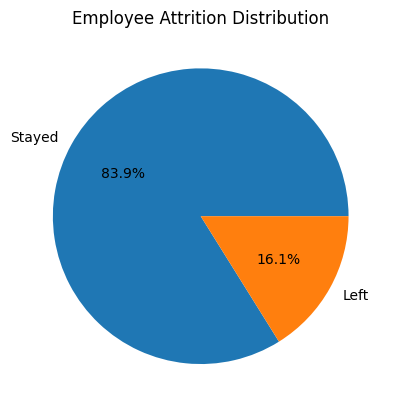

In [12]:
plt.pie(data['Attrition'].value_counts(), labels=['Stayed', 'Left'], autopct='%1.1f%%')
plt.title('Employee Attrition Distribution')    
plt.show()

* Approximately 16.1% of employees left the organization during the observed period. The following analysis investigates the factors most strongly associated with employee turnover.

# 1. Attrition by Department

In [13]:
dept_attrition = data.groupby('Department').agg({
    'Attrition': lambda x: (x=='Yes').sum(),
    'EmployeeNumber': 'count'
}).rename(columns={'Attrition': 'Employees Left', 'EmployeeNumber': 'Total Employees'})

In [14]:
dept_attrition

,Employees Left,Total Employees
Department,,
Human Resources,12,63
Research & Development,133,961
Sales,92,446


In [15]:
dept_attrition['Attrition Rate'] = round((dept_attrition['Employees Left'] / dept_attrition['Total Employees'])*100,2)
dept_attrition

,Employees Left,Total Employees,Attrition Rate
Department,,,
Human Resources,12,63,19.05
Research & Development,133,961,13.84
Sales,92,446,20.63


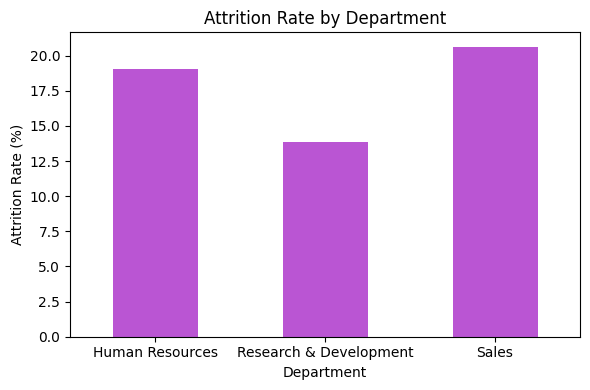

In [16]:
# Visualize attrition by department

plt.figure(figsize=(6,4))
dept_attrition['Attrition Rate'].plot(kind='bar', color='mediumorchid')
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* The Sales department exhibits the highest attrition rate (20.63%), followed by Human Resources (19.05%), while Research & Development shows comparatively lower employee turnover.

# 2. Attrition by Job Role

In [17]:
role_attrition = data.groupby('JobRole').agg(
    {'Attrition': lambda x: (x=='Yes').sum(),
     'EmployeeNumber': 'count'}
).rename(columns={'Attrition': 'Employees Left', 'EmployeeNumber': 'Total Employees'})

In [18]:
role_attrition

,Employees Left,Total Employees
JobRole,,
Healthcare Representative,9,131
Human Resources,12,52
Laboratory Technician,62,259
Manager,5,102
Manufacturing Director,10,145
Research Director,2,80
Research Scientist,47,292
Sales Executive,57,326
Sales Representative,33,83


In [19]:
role_attrition['Attrition Rate'] = round((role_attrition['Employees Left'] / role_attrition['Total Employees'])*100,2)
role_attrition.sort_values('Attrition Rate', ascending=False)

,Employees Left,Total Employees,Attrition Rate
JobRole,,,
Sales Representative,33,83,39.76
Laboratory Technician,62,259,23.94
Human Resources,12,52,23.08
Sales Executive,57,326,17.48
Research Scientist,47,292,16.10
Manufacturing Director,10,145,6.90
Healthcare Representative,9,131,6.87
Manager,5,102,4.90
Research Director,2,80,2.50


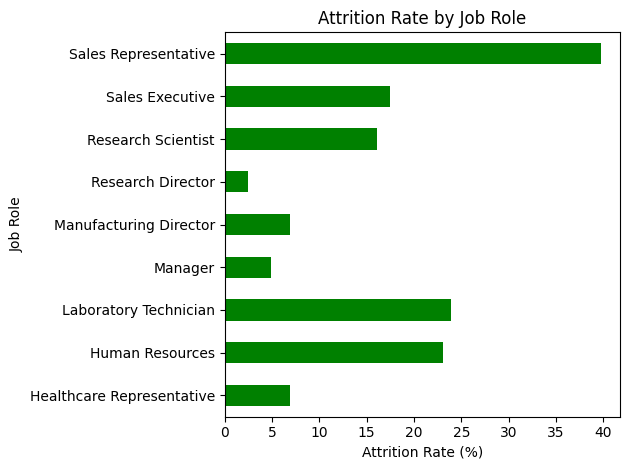

In [20]:
role_attrition['Attrition Rate'].plot(kind='barh', color='green')
plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

* Sales Representatives and Laboratory Technicians exhibit the highest attrition rates, suggesting that customer-facing and operational roles may experience greater turnover pressure than managerial or technical leadership positions.

# 3. Attrition by Monthly Income

In [21]:
data['MonthlyIncome'].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

In [22]:
bins = [0, 3000, 7000, 12000, float('inf')]
labels = ['Low', 'Medium', 'High', 'Very High']

data['Salary_Band'] = pd.cut(data['MonthlyIncome'], bins=bins, labels=labels, right=False)

data['Salary_Band'].value_counts()


Salary_Band
Medium       640
Low          395
High         240
Very High    195
Name: count, dtype: int64

In [23]:
salary_attrition = data.groupby('Salary_Band').agg(
    {'Attrition': lambda x: (x=='Yes').sum(),
    'EmployeeNumber': 'count'}
).rename(columns={'Attrition': 'Employees Left', 'EmployeeNumber': 'Total Employees'})

C:\Users\SRINIJA\AppData\Local\Temp\ipykernel_16992\2997458995.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_attrition = data.groupby('Salary_Band').agg(


In [24]:
salary_attrition

,Employees Left,Total Employees
Salary_Band,,
Low,113,395
Medium,77,640
High,36,240
Very High,11,195


In [25]:
salary_attrition['Attrition Rate'] = round((salary_attrition['Employees Left'] / salary_attrition['Total Employees'])*100,2)
salary_attrition.sort_values('Attrition Rate', ascending=False)

,Employees Left,Total Employees,Attrition Rate
Salary_Band,,,
Low,113,395,28.61
High,36,240,15.00
Medium,77,640,12.03
Very High,11,195,5.64


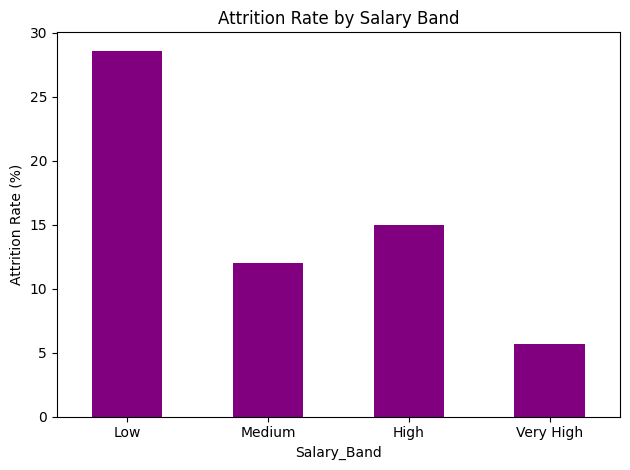

In [26]:
## Visualize attrition by salary band
salary_attrition['Attrition Rate'].plot(kind='bar', color='purple')
plt.title('Attrition Rate by Salary Band')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* Employees with the lowest salaries are the most likely to leave. Some higher‑income groups also show more turnover, but that result may not be reliable because there are fewer people in those groups.
 
* This may be because employees with low salary may be looking for better opportunities and employees with high salary may have more marketable skills and thus have more job options.

# 4. Attrition by Tenure (Years at Company)

In [27]:
tenure_attrition = data.groupby('YearsAtCompany').agg(
    {'Attrition': lambda x: (x=='Yes').sum(),
     'EmployeeNumber': 'count'}
).rename(columns={'Attrition': 'Employees Left', 'EmployeeNumber': 'Total Employees'})

In [28]:
tenure_attrition['Attrition Rate'] = round((tenure_attrition['Employees Left'] / tenure_attrition['Total Employees'])*100,2)
tenure_attrition.sort_values('Attrition Rate', ascending=False)

,Employees Left,Total Employees,Attrition Rate
YearsAtCompany,,,
40,1,1,100.00
23,1,2,50.00
0,16,44,36.36
1,59,171,34.50
32,1,3,33.33
31,1,3,33.33
2,27,127,21.26
33,1,5,20.00
4,19,110,17.27


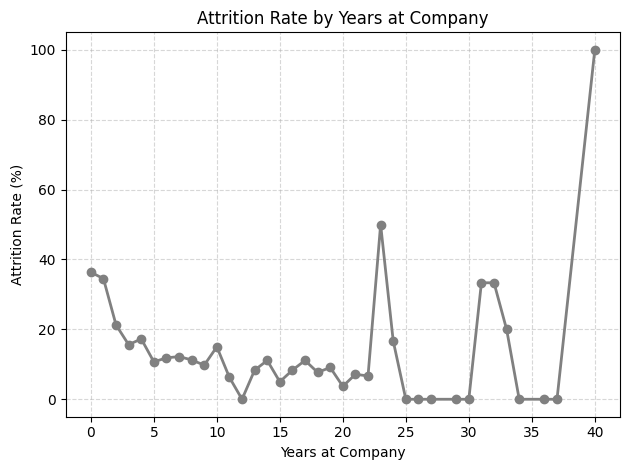

In [29]:
# Visualize attrition by tenure

plt.plot(tenure_attrition.index, tenure_attrition['Attrition Rate'], marker='o', color='grey', linewidth=2)
plt.title('Attrition Rate by Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Years at Company')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

* Employees with very short tenure (0–2 years) show the highest turnover, reflecting early‑career attrition. 
* A smaller group of employees with extremely long tenure (around 40 years) also leave at higher rates, likely due to retirement. 
* Mid‑career employees (22–24 years) display a modest spike in attrition, but overall the strongest pattern is that newer employees are the most at risk of leaving.

# 5. Attrition by Overtime

In [30]:
overtime_attrition = data.groupby('OverTime').agg({
    'Attrition': lambda x: (x=='Yes').sum(),
    'EmployeeNumber': 'count'
}).rename(columns={'Attrition': 'Employees Left', 'EmployeeNumber': 'Total Employees'})

In [31]:
overtime_attrition

,Employees Left,Total Employees
OverTime,,
No,110,1054
Yes,127,416


In [32]:
overtime_attrition['Attrition Rate'] = round((overtime_attrition['Employees Left'] / overtime_attrition['Total Employees'])*100,2)
overtime_attrition.sort_values('Attrition Rate', ascending=False)

,Employees Left,Total Employees,Attrition Rate
OverTime,,,
Yes,127,416,30.53
No,110,1054,10.44


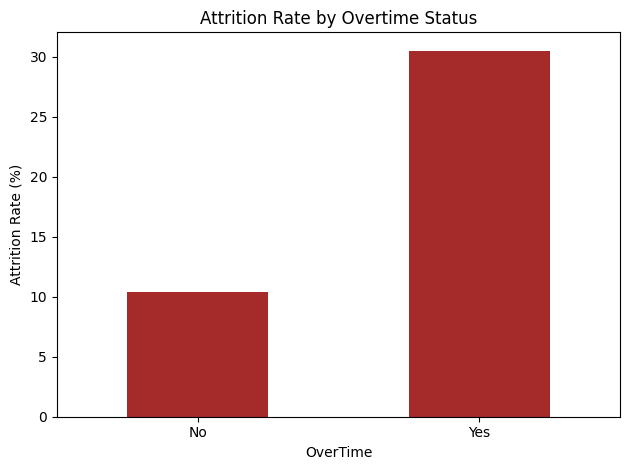

In [33]:
# visualize attrition by overtime status
overtime_attrition['Attrition Rate'].plot(kind='bar', color='brown')
plt.title('Attrition Rate by Overtime Status')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* we can see Employees working overtime exhibit significantly higher attrition rates(30.53).

# 6. Attrition by Department and Overtime

In [34]:
dept_overtime_attrition = data.groupby(['Department', 'OverTime']).agg(
    {'Attrition': lambda x: (x=='Yes').sum(),
     'EmployeeNumber': 'count'}
).rename(columns={'Attrition': 'Employees Left', 'EmployeeNumber': 'Total Employees'})

dept_overtime_attrition


Employees Left  Total Employees
Department             OverTime                                 
Human Resources        No                     7               46
                       Yes                    5               17
Research & Development No                    59              690
                       Yes                   74              271
Sales                  No                    44              318
                       Yes                   48              128

In [35]:
dept_overtime_attrition['Attrition Rate'] = round((dept_overtime_attrition['Employees Left'] / dept_overtime_attrition['Total Employees'])*100,2)
dept_overtime_attrition.sort_values('Attrition Rate', ascending=False)

,,Employees Left,Total Employees,Attrition Rate
Department,OverTime,,,
Sales,Yes,48,128,37.50
Human Resources,Yes,5,17,29.41
Research & Development,Yes,74,271,27.31
Human Resources,No,7,46,15.22
Sales,No,44,318,13.84
Research & Development,No,59,690,8.55


<Figure size 1000x600 with 0 Axes>

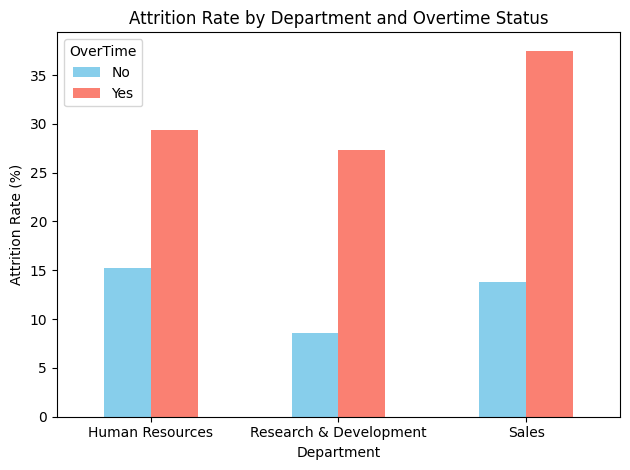

In [36]:
# Visualize attrition by department and overtime status

plt.figure(figsize=(10,6))
dept_overtime_attrition['Attrition Rate'].unstack().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Attrition Rate by Department and Overtime Status')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()  
plt.show()

* Employees who work overtime consistently show much higher attrition rates across all departments. The Sales department with overtime stands out as the highest‑risk group. The lowest attrition is in R&D employees without overtime.
* Overtime is strongly linked to higher turnover, especially in Sales.

# 7. Numerical Columns Comparison

In [37]:
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'DistanceFromHome', 
                'RelationshipSatisfaction', 'YearsInCurrentRole', 'YearsWithCurrManager',
                'EnvironmentSatisfaction', 'WorkLifeBalance', 'PerformanceRating']

In [38]:
comparison = pd.DataFrame({
    'Attrition_Avg': data[data['Attrition']=='Yes'][numeric_cols].mean(),
    'Retention_Avg': data[data['Attrition']=='No'][numeric_cols].mean()
})

comparison['difference'] = comparison['Retention_Avg'] - comparison['Attrition_Avg'] 
round(comparison,2)

,Attrition_Avg,Retention_Avg,difference
Age,33.61,37.56,3.95
MonthlyIncome,4787.09,6832.74,2045.65
YearsAtCompany,5.13,7.37,2.24
JobSatisfaction,2.47,2.78,0.31
DistanceFromHome,10.63,8.92,-1.72
RelationshipSatisfaction,2.60,2.73,0.13
YearsInCurrentRole,2.90,4.48,1.58
YearsWithCurrManager,2.85,4.37,1.52
EnvironmentSatisfaction,2.46,2.77,0.31
WorkLifeBalance,2.66,2.78,0.12


* Age: Employees who left are younger on average (33.6 vs 37.6).

* MonthlyIncome: Employees who left the organization earned lower average salaries than those who stayed.
(≈4.8k vs 6.8k).

* YearsAtCompany / YearsInCurrentRole / YearsWithCurrManager: Leavers have shorter tenure and less experience with their manager.

* JobSatisfaction / EnvironmentSatisfaction / RelationshipSatisfaction / WorkLifeBalance: Slightly lower satisfaction scores among leavers.

* DistanceFromHome: Leavers live farther away (10.6 vs 8.9).

* PerformanceRating: No difference (both ~3.15).

In [39]:
from scipy.stats import ttest_ind

for col in numeric_cols:
    stat, p = ttest_ind(
        data[data['Attrition']=='Yes'][col],
        data[data['Attrition']=='No'][col],
        equal_var=False
    )
    print(f"{col}: p-value = {p:.4f}")


Age: p-value = 0.0000
MonthlyIncome: p-value = 0.0000
YearsAtCompany: p-value = 0.0000
JobSatisfaction: p-value = 0.0001
DistanceFromHome: p-value = 0.0041
RelationshipSatisfaction: p-value = 0.0897
YearsInCurrentRole: p-value = 0.0000
YearsWithCurrManager: p-value = 0.0000
EnvironmentSatisfaction: p-value = 0.0002
WorkLifeBalance: p-value = 0.0305
PerformanceRating: p-value = 0.9125


Age (p=0.0000) → Highly significant. Employees who left are younger.

MonthlyIncome (p=0.0000) → Highly significant. Leavers earn less.

YearsAtCompany (p=0.0000) → Highly significant. Shorter tenure is linked to attrition.

JobSatisfaction (p=0.0001) → Significant. Lower satisfaction among leavers.

DistanceFromHome (p=0.0041) → Significant. Longer commute is associated with attrition.

RelationshipSatisfaction (p=0.0897) → Not significant (p > 0.05). No strong evidence that relationship satisfaction differs between groups.

YearsInCurrentRole (p=0.0000) → Significant. Leavers are newer in their roles.

YearsWithCurrManager (p=0.0000) → Significant. Less time with manager is linked to attrition.

EnvironmentSatisfaction (p=0.0002) → Significant. Lower satisfaction among leavers.

WorkLifeBalance (p=0.0305) → Significant, but weaker. Slightly worse work-life balance among leavers.

PerformanceRating (p=0.9125) → Not significant. Performance ratings are basically the same across both groups.

##### Interpretation:

Strong predictors of attrition: Age, MonthlyIncome, Tenure (YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager), JobSatisfaction, EnvironmentSatisfaction, DistanceFromHome.

Weak or no predictive power: RelationshipSatisfaction, PerformanceRating.

WorkLifeBalance: borderline — statistically significant but effect size is small.

##### Takeaway:

The t-test results indicate statistically significant differences (p < 0.05) between attrited and retained employees for Age, MonthlyIncome, JobSatisfaction and YearsAtCompany, suggesting these variables are meaningfully associated with employee turnover.

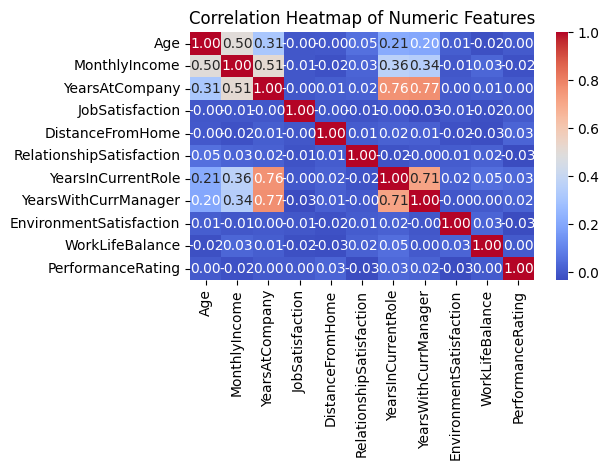

In [40]:
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## BUSINESS SUMMARY - ATTRITION RISK QUANTIFICATION


In [41]:
attrited_count = len(data[data['Attrition'] == 'Yes'])
total_employees = len(data)
attrition_rate = (attrited_count / total_employees) * 100

print("=" * 70)
print("HR ATTRITION EARLY WARNING SYSTEM — KEY FINDINGS")
print("=" * 70)
print(f"\nTotal Employees: {total_employees:,}")
print(f"Employees Attrited: {attrited_count:,}")
print(f"Attrition Rate: {attrition_rate:.2f}%")

# Calculate high-risk segments
first_year = data[(data['YearsAtCompany'] < 1) & (data['Attrition'] == 'Yes')].shape[0]
low_satisfaction = data[(data['JobSatisfaction'] <= 2) & (data['Attrition'] == 'Yes')].shape[0]
low_salary = data[(data['MonthlyIncome'] < 3000) & (data['Attrition'] == 'Yes')].shape[0]
overtime_workers = data[(data['OverTime'] == 'Yes') & (data['Attrition'] == 'Yes')].shape[0]

print(f"\nRisk Breakdown:")
print(f"  * First-year leavers: {first_year} ({round(first_year/attrited_count*100,1)}% of attrition)")
print(f"  * Low satisfaction leavers: {low_satisfaction} ({round(low_satisfaction/attrited_count*100,1)}% of attrition)")
print(f"  * Low salary leavers: {low_salary} ({round(low_salary/attrited_count*100,1)}% of attrition)")
print(f"  * Overtime workers who left: {overtime_workers} ({round(overtime_workers/attrited_count*100,1)}% of attrition)")

print(f"\nStrongest Predictors of Attrition (by p-value):")
print(f"  1. Age (p=0.0000) - Younger employees leave more")
print(f"  2. Monthly Income (p=0.0000) - Lower-paid employees leave more")
print(f"  3. Years at Company (p=0.0000) - Early tenure is high-risk period")
print(f"  4. Job Satisfaction (p=0.0001) - Major factor in retention decision")
print(f"  5. Years in Current Role (p=0.0000) - New-to-role employees at risk")

print(f"\nWeakest Predictors (not significant):")
print(f"  * Performance Rating (p=0.9125) - Top performers leave just as often")
print(f"  * Relationship Satisfaction (p=0.0897) - Borderline, not actionable")

print("\n" + "=" * 70)

HR ATTRITION EARLY WARNING SYSTEM — KEY FINDINGS

Total Employees: 1,470
Employees Attrited: 237
Attrition Rate: 16.12%

Risk Breakdown:
  * First-year leavers: 16 (6.8% of attrition)
  * Low satisfaction leavers: 112 (47.3% of attrition)
  * Low salary leavers: 113 (47.7% of attrition)
  * Overtime workers who left: 127 (53.6% of attrition)

Strongest Predictors of Attrition (by p-value):
  1. Age (p=0.0000) - Younger employees leave more
  2. Monthly Income (p=0.0000) - Lower-paid employees leave more
  3. Years at Company (p=0.0000) - Early tenure is high-risk period
  4. Job Satisfaction (p=0.0001) - Major factor in retention decision
  5. Years in Current Role (p=0.0000) - New-to-role employees at risk

Weakest Predictors (not significant):
  * Performance Rating (p=0.9125) - Top performers leave just as often
  * Relationship Satisfaction (p=0.0897) - Borderline, not actionable



In [42]:
len(data[(data['Attrition'] == 'No') & (data['YearsAtCompany'] < 1)])

28

In [43]:
len(data[(data['Attrition'] == 'No') & (data['YearsAtCompany'] < 1)])*100/len(data[data['Attrition'] == 'No'])

2.2708840227088403

In [44]:
len(data[(data['JobSatisfaction']<2) & (data['Attrition'] == 'No')])

223

In [45]:
len(data[(data['JobSatisfaction']<2) & (data['Attrition'] == 'No')])*100/len(data[data['Attrition'] == 'No'])

18.085969180859692

In [46]:
len(data[(data['MonthlyIncome'] < 2500) & (data['Attrition'] == 'No')])

147

In [47]:
len(data[(data['MonthlyIncome'] < 2500) & (data['Attrition'] == 'No')]) * 100 / len(data[data['Attrition'] == 'No'])

11.922141119221411

In [48]:
len(data[(data['WorkLifeBalance']<2) & (data['Attrition'] == 'No')])

55

In [49]:
len(data[(data['WorkLifeBalance']<2) & (data['Attrition'] == 'No')])*100/len(data[data['Attrition'] == 'No'])

4.4606650446066505

In [50]:
len(data[(data['OverTime']=='Yes') & (data['Attrition'] == 'No')])

289

In [51]:
len(data[(data['OverTime']=='Yes') & (data['Attrition'] == 'No')]) * 100 / len(data[data['Attrition'] == 'No'])

23.438767234387672

## ACTIVE EMPLOYEE RISK ASSESSMENT

In [52]:
# Filter to only ACTIVE employees (Attrition = No)
active_employees = data[data['Attrition'] == 'No'].copy()

print(f"Total Active Employees: {len(active_employees)}")

Total Active Employees: 1233


## DEFINE RISK FACTORS

In [53]:
# create a risk score column, each factor = 1 point
active_employees['Risk_Score'] = 0

# Risk factor 1: OverTime = Yes
active_employees.loc[active_employees['OverTime'] == 'Yes', 'Risk_Score'] += 1

# Risk factor 2: Low JobSatisfaction <= 2 (on a scale of 1-4)
active_employees.loc[active_employees['JobSatisfaction'] <= 2, 'Risk_Score'] += 1

# Risk factor 3: Poor WorkLifeBalance <= 2 (on a scale of 1-4)
active_employees.loc[active_employees['WorkLifeBalance'] <= 2, 'Risk_Score'] += 1

# Risk factor 4: Low MonthlyIncome (bottom quartile)
income_q1 = active_employees['MonthlyIncome'].quantile(0.25)
active_employees.loc[active_employees['MonthlyIncome'] <= income_q1, 'Risk_Score'] += 1

# Risk factor 5: Early tenure (< 2 years)
active_employees.loc[active_employees['YearsAtCompany'] < 2, 'Risk_Score'] += 1

print(f"Income Q1 (25th percentile): {income_q1:.2f}")

Income Q1 (25th percentile): 3211.00


## CATEGORIZE EMPLOYEES INTO RISK LEVELS

In [55]:
def assign_risk_level(score):
    if score >= 3 :
        return 'High Risk'
    elif score == 2:
        return 'Medium Risk'
    else:
        return 'Low Risk'
    
active_employees['Risk_Level'] = active_employees['Risk_Score'].apply(assign_risk_level)

print("\n" + "=" * 70)
print("Active Employees Risk Level Distribution")
print("=" * 70)

risk_distribution = active_employees['Risk_Level'].value_counts()
print(risk_distribution)

risk_pct = active_employees['Risk_Level'].value_counts(normalize=True) * 100
print("\nRisk Level Percentage:")
for level, pct in risk_pct.items():
    print(f"  {level}: {pct:.2f}%")


Active Employees Risk Level Distribution
Risk_Level
Low Risk       797
Medium Risk    310
High Risk      126
Name: count, dtype: int64

Risk Level Percentage:
  Low Risk: 64.64%
  Medium Risk: 25.14%
  High Risk: 10.22%


## BREAKDOWN BY RISK FACTORS  HOW MANY EMPLOYEES HAVE EACH RISK FACTOR

In [56]:
print("\n" + "=" * 70)
print("Risk Factor Prevalence Among Active Employees")
print("=" * 70)

overtime_count = (active_employees['OverTime']=='Yes').sum()
job_satisfaction_count = (active_employees['JobSatisfaction'] <= 2).sum()
worklife_balance_count = (active_employees['WorkLifeBalance'] <= 2).sum()
low_income_count = (active_employees['MonthlyIncome'] <= income_q1).sum()
early_tenure_count = (active_employees['YearsAtCompany'] < 2).sum()

print(f"  Overtime Workers: {overtime_count} ({round(overtime_count/len(active_employees)*100,1)}%)")
print(f"  Low Job Satisfaction: {job_satisfaction_count} ({round(job_satisfaction_count/len(active_employees)*100,1)}%)")
print(f"  Poor Work-Life Balance: {worklife_balance_count} ({round(worklife_balance_count/len(active_employees)*100,1)}%)")
print(f"  Low Income (<= {income_q1:.2f}): {low_income_count} ({round(low_income_count/len(active_employees)*100,1)}%)")
print(f"  Early Tenure (< 2 years): {early_tenure_count} ({round(early_tenure_count/len(active_employees)*100,1)}%)")


Risk Factor Prevalence Among Active Employees
  Overtime Workers: 289 (23.4%)
  Low Job Satisfaction: 457 (37.1%)
  Poor Work-Life Balance: 341 (27.7%)
  Low Income (<= 3211.00): 309 (25.1%)
  Early Tenure (< 2 years): 140 (11.4%)


##  HIGH RISK EMPLOYEES - DETAILED VIEW

In [62]:
print("\n" + "=" * 70)
print("High Risk Active Employees (3+ Risk Factors)")
print("=" * 70)

high_risk = active_employees[active_employees['Risk_Level'] == 'High Risk'].sort_values('Risk_Score', ascending=False)
print(f"Total High Risk Employees: {len(high_risk)} employees")

print("\n Top 10 High Risk Employees:")
print(high_risk[['EmployeeNumber', 'Age', 'Department', 'JobRole', 'MonthlyIncome', 
                  'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance', 'OverTime', 
                  'Risk_Score', 'Risk_Level']].head(10))


High Risk Active Employees (3+ Risk Factors)
Total High Risk Employees: 126 employees

 Top 10 High Risk Employees:
     EmployeeNumber  Age              Department                 JobRole  \
6                10   59  Research & Development   Laboratory Technician   
17               22   22  Research & Development   Laboratory Technician   
170             233   27  Research & Development      Research Scientist   
206             284   22  Research & Development      Research Scientist   
157             214   58  Research & Development      Research Scientist   
164             224   27  Research & Development      Research Scientist   
242             334   41  Research & Development      Research Scientist   
559             773   38  Research & Development      Research Scientist   
389             518   37  Research & Development  Manufacturing Director   
577             802   37  Research & Development      Research Scientist   

     MonthlyIncome  YearsAtCompany  JobSatisfa

## EXPORT RISK DATA FOR POWER BI


In [64]:
# Create summary table for Power BI
risk_summary = pd.DataFrame({
    'Risk Level': ['High Risk', 'Medium Risk', 'Low Risk'],
    'Employee Count': [
        len(active_employees[active_employees['Risk_Level'] == 'High Risk']),
        len(active_employees[active_employees['Risk_Level'] == 'Medium Risk']),
        len(active_employees[active_employees['Risk_Level'] == 'Low Risk'])
    ]
})

risk_summary['Percentage'] = (risk_summary['Employee Count'] / len(active_employees) * 100).round(2)
print("\n" + "="*70)
print("RISK SUMMARY TABLE (for Power BI)")
print("="*70)
print(risk_summary)


RISK SUMMARY TABLE (for Power BI)
    Risk Level  Employee Count  Percentage
0    High Risk             126       10.22
1  Medium Risk             310       25.14
2     Low Risk             797       64.64


In [67]:
# Export active employees with risk scores to CSV for Power BI
active_employees_export = active_employees[['EmployeeNumber', 'Age', 'Department', 'JobRole', 
                                             'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 
                                             'WorkLifeBalance', 'OverTime',
                                             'Risk_Score', 'Risk_Level']]

active_employees_export.to_csv('active_employees_risk_scores.csv', index=False)
print("\n Exported: active_employees_risk_scores.csv")



 Exported: active_employees_risk_scores.csv


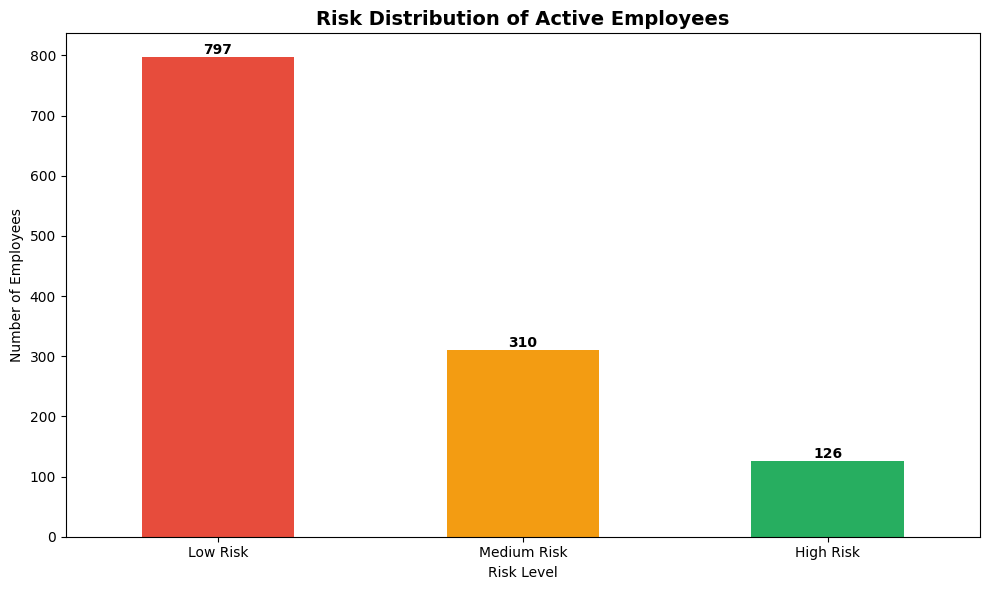


 Saved: active_employee_risk_distribution.png


In [68]:
# Also create visualization
plt.figure(figsize=(10, 6))
risk_distribution.plot(kind='bar', color=['#E74C3C', '#F39C12', '#27AE60'])
plt.title('Risk Distribution of Active Employees', fontsize=14, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
for i, v in enumerate(risk_distribution):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('active_employee_risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Saved: active_employee_risk_distribution.png")
